Trial 5 Complete [00h 00m 14s]
val_accuracy: 0.86080002784729

Best val_accuracy So Far: 0.8795999884605408
Total elapsed time: 00h 01m 18s

Hyperparameter search complete.
  Best Embedding Dim : 32
  Best LSTM Units    : 32
  Best Dropout Rate  : 0.2
  Best Learning Rate : 0.01

Epoch 1/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7272 - loss: 0.5235 - val_accuracy: 0.7914 - val_loss: 0.4449
Epoch 2/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8888 - loss: 0.2768 - val_accuracy: 0.8710 - val_loss: 0.3018
Epoch 3/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9385 - loss: 0.1710 - val_accuracy: 0.8710 - val_loss: 0.3370
Epoch 4/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9651 - loss: 0.1057 - val_accuracy: 0.8670 - val_loss: 0.3873
Epoch 5/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9763 - loss: 0.0707 - val_accuracy: 0.8704 - val_loss: 0.4957
Epoch 6/7
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9811 - loss: 

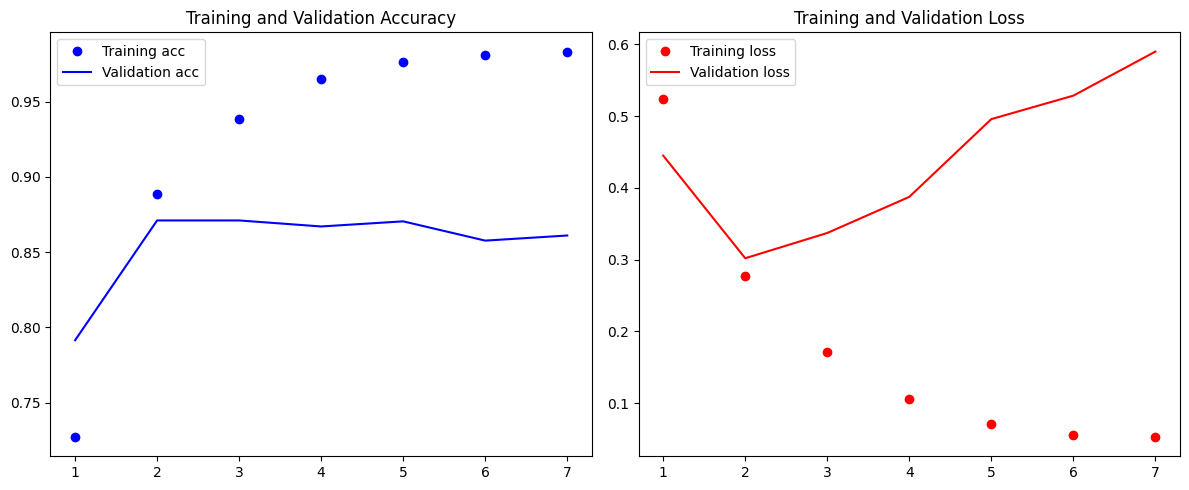


Evaluating on Test Data...
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8462 - loss: 0.6480
Test Accuracy : 84.62%
Test Loss     : 0.6480
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Text  : 'This movie was absolutely fantastic and thrilling'
Score : 0.0705
Sentiment : NEGATIVE

Text  : 'I hated every moment of it, terrible acting'
Score : 0.8888
Sentiment : POSITIVE

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


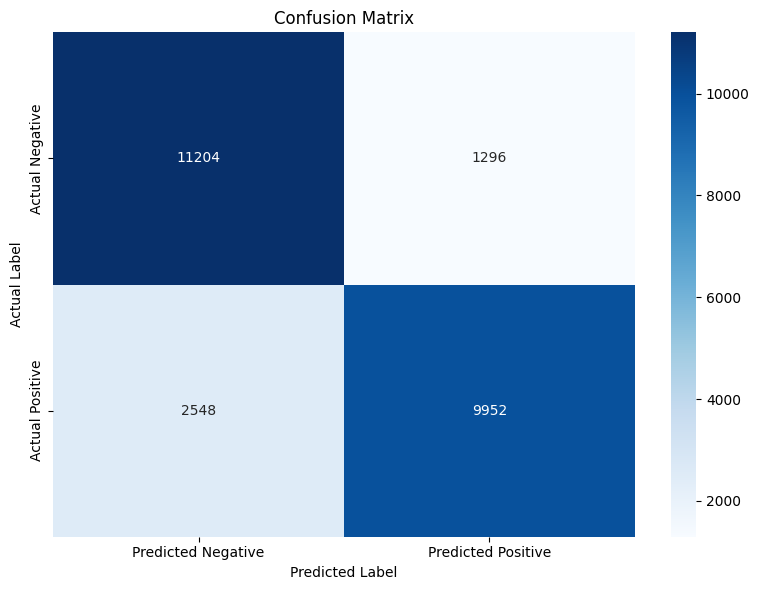

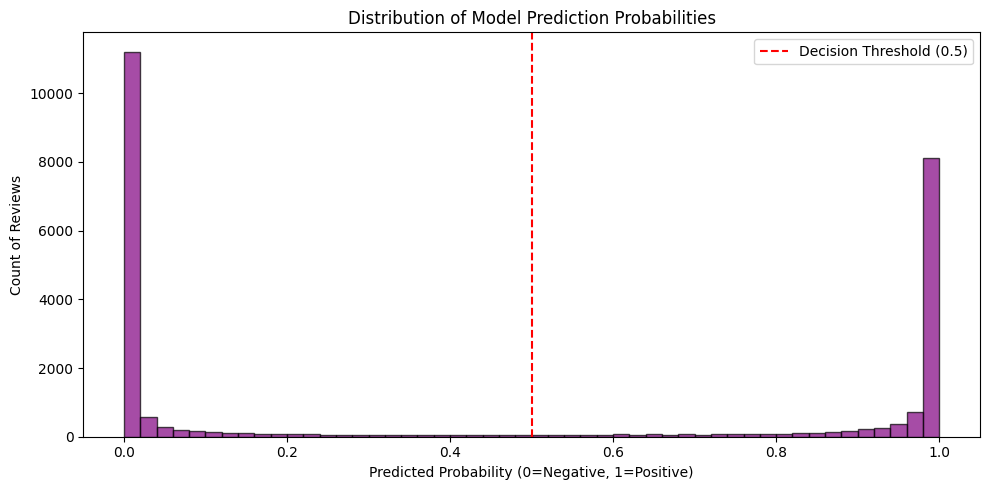

REPORT SUMMARY
Best Embedding Dim : 32
Best LSTM Units    : 32
Best Dropout Rate  : 0.2
Best Learning Rate : 0.01
Final Test Accuracy: 84.62%
Final Test Loss    : 0.6480
Training Accuracy  : 98.32%
Validation Accuracy: 86.10%

Confusion Matrix:
[[11204  1296]
 [ 2548  9952]]


In [1]:
# ============================================================
# ML & DL : Experiment 9
# RNN / LSTM for Sentiment Classification (IMDB Dataset)
# ============================================================

# ── Step 0: Install Keras Tuner ──────────────────────────────
!pip install keras-tuner --quiet

# ── Step 1: Imports & Config ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

MAX_FEATURES = 10000
MAX_LEN = 200

# ── Step 2: Load & Pad Data ──────────────────────────────────
print("Loading IMDB data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)
print(f"Training sequences : {len(x_train)}")
print(f"Test sequences     : {len(x_test)}")

x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN)
print(f"Shape after padding: {x_train.shape}")

# ── Step 3: Model Builder for Keras Tuner ───────────────────
def build_model(hp):
    model = Sequential()
    model.add(Embedding(
        input_dim=MAX_FEATURES,
        output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
        input_length=MAX_LEN
    ))
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=128, step=32)))
    model.add(Dropout(rate=hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ── Step 4: Hyperparameter Search ───────────────────────────
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='my_dir',
    project_name='imdb_lstm_tuning'
)

tuner.search_space_summary()
print("\nStarting Hyperparameter Search...")
tuner.search(x_train, y_train, epochs=3, validation_split=0.2, batch_size=64)

# ── Step 5: Best Hyperparameters ────────────────────────────
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"""
Hyperparameter search complete.
  Best Embedding Dim : {best_hps.get('embedding_dim')}
  Best LSTM Units    : {best_hps.get('lstm_units')}
  Best Dropout Rate  : {best_hps.get('dropout_rate')}
  Best Learning Rate : {best_hps.get('learning_rate')}
""")

# ── Step 6: Final Training ───────────────────────────────────
model = tuner.hypermodel.build(best_hps)
history = model.fit(
    x_train, y_train,
    epochs=7,
    validation_split=0.2,
    batch_size=64
)

# ── Step 7: Training & Validation Curves ────────────────────
acc     = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss    = history.history['loss']
val_loss= history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc,     'bo', label='Training acc')
plt.plot(epochs_range, val_acc, 'b',  label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss,     'ro', label='Training loss')
plt.plot(epochs_range, val_loss, 'r',  label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# ── Step 8: Test Evaluation ──────────────────────────────────
print("\nEvaluating on Test Data...")
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# ── Step 9: Sentiment Prediction Demo ───────────────────────
word_index = imdb.get_word_index()

def predict_sentiment(text):
    tokens = [word_index.get(w, 0) for w in text.lower().split()]
    padded = pad_sequences([tokens], maxlen=MAX_LEN)
    score  = model.predict(padded, verbose=0)[0][0]
    label  = "POSITIVE" if score > 0.5 else "NEGATIVE"
    print(f"Text  : '{text}'")
    print(f"Score : {score:.4f}")
    print(f"Sentiment : {label}\n")

predict_sentiment("This movie was absolutely fantastic and thrilling")
predict_sentiment("I hated every moment of it, terrible acting")

# ── Step 10: Confusion Matrix ────────────────────────────────
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative',    'Actual Positive'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── Step 11: Prediction Probability Distribution ─────────────
plt.figure(figsize=(10, 5))
plt.hist(y_pred_probs, bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.title('Distribution of Model Prediction Probabilities')
plt.xlabel('Predicted Probability (0=Negative, 1=Positive)')
plt.ylabel('Count of Reviews')
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=150)
plt.show()

# ── Step 12: Print all key values for the report ─────────────
print("=" * 50)
print("REPORT SUMMARY")
print("=" * 50)
print(f"Best Embedding Dim : {best_hps.get('embedding_dim')}")
print(f"Best LSTM Units    : {best_hps.get('lstm_units')}")
print(f"Best Dropout Rate  : {best_hps.get('dropout_rate')}")
print(f"Best Learning Rate : {best_hps.get('learning_rate')}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
print(f"Final Test Loss    : {test_loss:.4f}")
print(f"Training Accuracy  : {acc[-1]*100:.2f}%")
print(f"Validation Accuracy: {val_acc[-1]*100:.2f}%")
print(f"\nConfusion Matrix:\n{cm}")